In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# # Plot
# valuesx = [5,7,8,7,2,17,1,9,4,11,12,9,6]
# valuesy = [10,6,3,9,11,6,2,6,12,7,4,8,9]

# plt.ylabel('Y Axis Label')
# plt.xlabel('X Axis Label')
# plt.scatter(valuesx, valuesy)
# plt.show()

In [3]:
# #Plot01
# valuesx = [5,7,8,7,2,17,1,9,4,11,12,9,6]
# valuesy = [10,6,1,9,11,6,2,6,12,7,4,8,9]

# plt.ylabel('Y Axis Label')
# plt.xlabel('X Axis Label')
# plt.scatter(valuesx, valuesy)
# plt.show()

In [4]:
# #Plot02
# valuesx = [80, 85, 43, 55, 77, 82]
# valuesy = [7, 11, 23, 34, 42, 28]

# plt.ylabel('Y Axis Label')
# plt.xlabel('X Axis Label')
# plt.scatter(valuesx, valuesy)
# plt.show()

In [5]:
ImageNumber = 52

In [6]:
#image = cv2.imread("C:/Users/DELL1/Pictures/basicPlot.png")
# image = cv2.imread("C:/Users/DELL1/Pictures/basicPlotBars.png")
#image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Bar/Master.jpg")
#image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Scatter/scatterPlot01.png")
image = cv2.imread(f'c:\\College\\Sem 08\\Major Project\\Graphs\\Scatter\\Testing\\testImages\\{ImageNumber}\\{ImageNumber}.png')

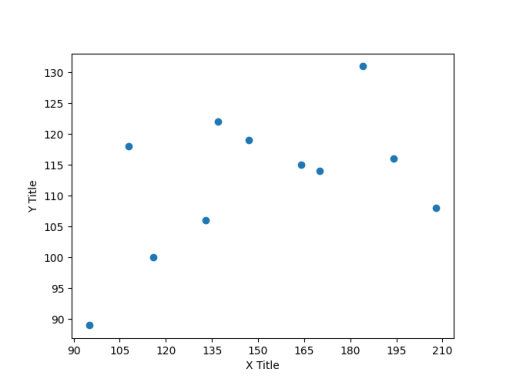

In [7]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [8]:
ab = 7
bc = 7

In [9]:
height, width, channels = image.shape
height_part = height//ab
width_part = width//bc

In [10]:
first_verti = image[:, :width_part]
last_hori = image[-height_part:, :]

In [11]:
cv2.imshow('First Vertical Strip', first_verti)
cv2.imshow('Last Horiontal Strip', last_hori)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [12]:
grey_first_verti = cv2.cvtColor(first_verti, cv2.COLOR_BGR2GRAY)
grey_last_hori = cv2.cvtColor(last_hori, cv2.COLOR_BGR2GRAY)

cv2.imshow('Grey Scale Strip Verti', grey_first_verti)
cv2.imshow('Grey Scale Strip Horiz', grey_last_hori)

cv2.waitKey(0)
cv2.destroyAllWindows()

X-Axis

In [13]:
import keras_ocr

pipeline = keras_ocr.pipeline.Pipeline()

images = [keras_ocr.tools.read(last_hori)]

predictions = pipeline.recognize(images)

imageWithBoxKeras = last_hori.copy()

for prediction in predictions[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKeras, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKeras)
cv2.waitKey(0)
cv2.destroyAllWindows() 

Looking for C:\Users\DELL1\.keras-ocr\craft_mlt_25k.h5
Instructions for updating:
Use `tf.image.resize(...method=ResizeMethod.BILINEAR...)` instead.
Looking for C:\Users\DELL1\.keras-ocr\crnn_kurapan.h5
1/1 [==============================] - 3s 3s/step


In [14]:
import pandas as pd

def predictions_to_dataframe(predictions):
    data_for_df = []
    
    for prediction in predictions[0]:  
        text, box = prediction
        x_center = (box[:, 0].min() + box[:, 0].max()) / 2
        y_center = (box[:, 1].min() + box[:, 1].max()) / 2
        box_width = box[:, 0].max() - box[:, 0].min()
        box_height = box[:, 1].max() - box[:, 1].min()
        box = box
        data_for_df.append({
            'text': text,
            'x_center': x_center, 
            'y_center': y_center, 
            'box_height': box_height, 
            'box_width': box_width,
            'box': box
        })
    
    return pd.DataFrame(data_for_df)

In [15]:
df = predictions_to_dataframe(predictions)
df

,text,x_center,y_center,box_height,box_width,box
0,90,84.0,31.5,13.0,18.0,"[[75.0, 25.0], [93.0, 25.0], [93.0, 38.0], [75..."
1,105,143.0,31.5,13.0,26.0,"[[130.0, 25.0], [156.0, 25.0], [156.0, 38.0], ..."
2,120,203.5,31.5,13.0,27.0,"[[190.0, 25.0], [217.0, 25.0], [217.0, 38.0], ..."
3,155,263.0,31.5,13.0,26.0,"[[250.0, 25.0], [276.0, 25.0], [276.0, 38.0], ..."
4,150,322.5,31.5,13.0,27.0,"[[309.0, 25.0], [336.0, 25.0], [336.0, 38.0], ..."
5,165,382.5,31.5,13.0,27.0,"[[369.0, 25.0], [396.0, 25.0], [396.0, 38.0], ..."
6,180,442.5,31.5,13.0,27.0,"[[429.0, 25.0], [456.0, 25.0], [456.0, 38.0], ..."
7,195,502.5,31.5,13.0,27.0,"[[489.0, 25.0], [516.0, 25.0], [516.0, 38.0], ..."
8,210,562.0,31.5,13.0,28.0,"[[548.0, 25.0], [576.0, 25.0], [576.0, 38.0], ..."
9,title,335.0,50.0,14.0,32.0,"[[319.0, 43.0], [351.0, 43.0], [351.0, 57.0], ..."


X-Axis Label

In [16]:
yMax = df['y_center'].mode()[0]
yMax

31.5

In [17]:
x_label = df[(df['y_center'] >= (yMax - 5)) & (df['y_center'] <= (yMax + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_label = x_label[x_label['text'].str.isdigit()]
x_label['text'] = x_label['text'].astype(float)
x_label

,text,x_center,y_center,box_height,box_width,box
0,90.0,84.0,31.5,13.0,18.0,"[[75.0, 25.0], [93.0, 25.0], [93.0, 38.0], [75..."
1,105.0,143.0,31.5,13.0,26.0,"[[130.0, 25.0], [156.0, 25.0], [156.0, 38.0], ..."
2,120.0,203.5,31.5,13.0,27.0,"[[190.0, 25.0], [217.0, 25.0], [217.0, 38.0], ..."
3,155.0,263.0,31.5,13.0,26.0,"[[250.0, 25.0], [276.0, 25.0], [276.0, 38.0], ..."
4,150.0,322.5,31.5,13.0,27.0,"[[309.0, 25.0], [336.0, 25.0], [336.0, 38.0], ..."
5,165.0,382.5,31.5,13.0,27.0,"[[369.0, 25.0], [396.0, 25.0], [396.0, 38.0], ..."
6,180.0,442.5,31.5,13.0,27.0,"[[429.0, 25.0], [456.0, 25.0], [456.0, 38.0], ..."
7,195.0,502.5,31.5,13.0,27.0,"[[489.0, 25.0], [516.0, 25.0], [516.0, 38.0], ..."
8,210.0,562.0,31.5,13.0,28.0,"[[548.0, 25.0], [576.0, 25.0], [576.0, 38.0], ..."


In [18]:
x_label['diff'] = (x_label['text'].diff(periods=-1).abs())
x_label['pdiff'] = (x_label['x_center'].diff(periods=-1).abs())
x_label['vpp'] = (x_label['text'].diff(periods=-1).abs())/x_label['x_center'].diff(periods=-1).abs()
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,90.0,84.0,31.5,13.0,18.0,"[[75.0, 25.0], [93.0, 25.0], [93.0, 38.0], [75...",15.0,59.0,0.254237
1,105.0,143.0,31.5,13.0,26.0,"[[130.0, 25.0], [156.0, 25.0], [156.0, 38.0], ...",15.0,60.5,0.247934
2,120.0,203.5,31.5,13.0,27.0,"[[190.0, 25.0], [217.0, 25.0], [217.0, 38.0], ...",35.0,59.5,0.588235
3,155.0,263.0,31.5,13.0,26.0,"[[250.0, 25.0], [276.0, 25.0], [276.0, 38.0], ...",5.0,59.5,0.084034
4,150.0,322.5,31.5,13.0,27.0,"[[309.0, 25.0], [336.0, 25.0], [336.0, 38.0], ...",15.0,60.0,0.250000
5,165.0,382.5,31.5,13.0,27.0,"[[369.0, 25.0], [396.0, 25.0], [396.0, 38.0], ...",15.0,60.0,0.250000
6,180.0,442.5,31.5,13.0,27.0,"[[429.0, 25.0], [456.0, 25.0], [456.0, 38.0], ...",15.0,60.0,0.250000
7,195.0,502.5,31.5,13.0,27.0,"[[489.0, 25.0], [516.0, 25.0], [516.0, 38.0], ...",15.0,59.5,0.252101
8,210.0,562.0,31.5,13.0,28.0,"[[548.0, 25.0], [576.0, 25.0], [576.0, 38.0], ...",NaN,NaN,NaN


In [19]:
most_common_diff_x = x_label['diff'][:-1].mode()[0]
most_common_diff_x

15.0

In [20]:
x_label['roundedVPP'] = x_label['vpp'].round(2)
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,84.0,31.5,13.0,18.0,"[[75.0, 25.0], [93.0, 25.0], [93.0, 38.0], [75...",15.0,59.0,0.254237,0.25
1,105.0,143.0,31.5,13.0,26.0,"[[130.0, 25.0], [156.0, 25.0], [156.0, 38.0], ...",15.0,60.5,0.247934,0.25
2,120.0,203.5,31.5,13.0,27.0,"[[190.0, 25.0], [217.0, 25.0], [217.0, 38.0], ...",35.0,59.5,0.588235,0.59
3,155.0,263.0,31.5,13.0,26.0,"[[250.0, 25.0], [276.0, 25.0], [276.0, 38.0], ...",5.0,59.5,0.084034,0.08
4,150.0,322.5,31.5,13.0,27.0,"[[309.0, 25.0], [336.0, 25.0], [336.0, 38.0], ...",15.0,60.0,0.250000,0.25
5,165.0,382.5,31.5,13.0,27.0,"[[369.0, 25.0], [396.0, 25.0], [396.0, 38.0], ...",15.0,60.0,0.250000,0.25
6,180.0,442.5,31.5,13.0,27.0,"[[429.0, 25.0], [456.0, 25.0], [456.0, 38.0], ...",15.0,60.0,0.250000,0.25
7,195.0,502.5,31.5,13.0,27.0,"[[489.0, 25.0], [516.0, 25.0], [516.0, 38.0], ...",15.0,59.5,0.252101,0.25
8,210.0,562.0,31.5,13.0,28.0,"[[548.0, 25.0], [576.0, 25.0], [576.0, 38.0], ...",NaN,NaN,NaN,NaN


In [21]:
mostCommonValue_x = x_label['roundedVPP'].value_counts().idxmax()
mostCommonIndex_x = x_label[x_label['roundedVPP'] == mostCommonValue_x].index[0]
mostCommonIndex_x

0

In [22]:
most_common_vpp_x = x_label['vpp'].iloc[mostCommonIndex_x]
# most_common_vpp_x = x_label['vpp'][:-1].mode()[0]

# if most_common_vpp_x == 0:
#     frequency_x = x_label['vpp'].value_counts()

#     if len(frequency_x) > 1:
#         most_common_vpp_x = frequency_x.index[1] 

most_common_vpp_x

0.2542372881355932

In [23]:
inRange_x = x_label['vpp'].between(most_common_vpp_x - 0.05, most_common_vpp_x + 0.05)

x_label = x_label[inRange_x | (x_label.index == x_label.index[-1])]
#x_label = x_label.drop(columns=['diff'])

x_label.reset_index(drop=True, inplace=True)
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,84.0,31.5,13.0,18.0,"[[75.0, 25.0], [93.0, 25.0], [93.0, 38.0], [75...",15.0,59.0,0.254237,0.25
1,105.0,143.0,31.5,13.0,26.0,"[[130.0, 25.0], [156.0, 25.0], [156.0, 38.0], ...",15.0,60.5,0.247934,0.25
2,150.0,322.5,31.5,13.0,27.0,"[[309.0, 25.0], [336.0, 25.0], [336.0, 38.0], ...",15.0,60.0,0.250000,0.25
3,165.0,382.5,31.5,13.0,27.0,"[[369.0, 25.0], [396.0, 25.0], [396.0, 38.0], ...",15.0,60.0,0.250000,0.25
4,180.0,442.5,31.5,13.0,27.0,"[[429.0, 25.0], [456.0, 25.0], [456.0, 38.0], ...",15.0,60.0,0.250000,0.25
5,195.0,502.5,31.5,13.0,27.0,"[[489.0, 25.0], [516.0, 25.0], [516.0, 38.0], ...",15.0,59.5,0.252101,0.25
6,210.0,562.0,31.5,13.0,28.0,"[[548.0, 25.0], [576.0, 25.0], [576.0, 38.0], ...",NaN,NaN,NaN,NaN


In [24]:
indexToDrop_x  = []
iii_x = 0
jjj_x = 1

if (x_label['diff'].iloc[0] != most_common_diff_x) or (most_common_vpp_x - 0.05 <= x_label['diff'].iloc[0] <= most_common_vpp_x + 0.05):
    indexToDrop_x.append(0)
    iii_x = jjj_x
    jjj_x += 1

In [25]:
while jjj_x != (len(x_label)):
    kkk_x = x_label['text'][iii_x] - x_label['text'][jjj_x]
    
    if kkk_x < 0:
       iii_x = jjj_x
       jjj_x += 1
    else:
        indexToDrop_x.append(jjj_x)
        jjj_x+=1
    
indexToDrop_x

[]

In [26]:
for i in range(len(x_label)):
    if i in indexToDrop_x:
        x_label.drop(index=i, inplace=True)
        
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,84.0,31.5,13.0,18.0,"[[75.0, 25.0], [93.0, 25.0], [93.0, 38.0], [75...",15.0,59.0,0.254237,0.25
1,105.0,143.0,31.5,13.0,26.0,"[[130.0, 25.0], [156.0, 25.0], [156.0, 38.0], ...",15.0,60.5,0.247934,0.25
2,150.0,322.5,31.5,13.0,27.0,"[[309.0, 25.0], [336.0, 25.0], [336.0, 38.0], ...",15.0,60.0,0.250000,0.25
3,165.0,382.5,31.5,13.0,27.0,"[[369.0, 25.0], [396.0, 25.0], [396.0, 38.0], ...",15.0,60.0,0.250000,0.25
4,180.0,442.5,31.5,13.0,27.0,"[[429.0, 25.0], [456.0, 25.0], [456.0, 38.0], ...",15.0,60.0,0.250000,0.25
5,195.0,502.5,31.5,13.0,27.0,"[[489.0, 25.0], [516.0, 25.0], [516.0, 38.0], ...",15.0,59.5,0.252101,0.25
6,210.0,562.0,31.5,13.0,28.0,"[[548.0, 25.0], [576.0, 25.0], [576.0, 38.0], ...",NaN,NaN,NaN,NaN


Value Per Pixel: X-Axis

In [27]:
# vpp_x = 0
# tot = len(x_label)-1

# for i in range (tot):
#     vpp_x += abs(x_label['text'][i+1] - x_label['text'][i])/abs(x_label['x_center'][i+1] - x_label['x_center'][i])
    
# vpp_x = vpp_x/tot
# vpp_x

In [28]:
vpp_x = x_label['vpp'][:-1].mean()
vpp_x

0.25071200212820804

X-Axis Title

In [29]:
x_title = df[df['y_center'] > (yMax + 5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,x,311.5,50.5,13.0,13.0,"[[305.0, 44.0], [318.0, 44.0], [318.0, 57.0], ..."
1,title,335.0,50.0,14.0,32.0,"[[319.0, 43.0], [351.0, 43.0], [351.0, 57.0], ..."


In [30]:
yMax1 = x_title['y_center'].mode()[0]
yMax1

50.0

In [31]:
x_title = x_title[(x_title['y_center'] >= (yMax1 - 5)) & (x_title['y_center'] <= (yMax1 + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,x,311.5,50.5,13.0,13.0,"[[305.0, 44.0], [318.0, 44.0], [318.0, 57.0], ..."
1,title,335.0,50.0,14.0,32.0,"[[319.0, 43.0], [351.0, 43.0], [351.0, 57.0], ..."


In [32]:
xtitle = ''

for indx in x_title.index:
    xtitle += x_title['text'][indx] + ' '
        
xtitle = xtitle.strip()
xtitle

'x title'

X-Axis Detection

In [33]:
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=int)

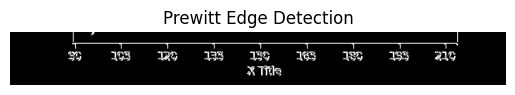

In [34]:
img_prewittx = cv2.filter2D(grey_last_hori, -1, kernelx)
img_prewitty = cv2.filter2D(grey_last_hori, -1, kernely)

img_prewitt = img_prewittx + img_prewitty

plt.imshow(img_prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

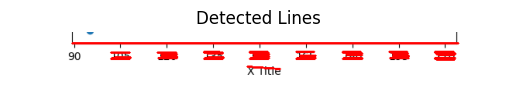

In [35]:
linesInLastHori = last_hori.copy()

_, binary_prewitt = cv2.threshold(img_prewitt, 50, 255, cv2.THRESH_BINARY)
linesP = cv2.HoughLinesP(binary_prewitt, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInLastHori, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
linesInLastHori = cv2.cvtColor(linesInLastHori, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

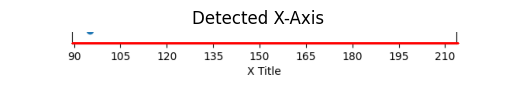

In [36]:
xAxisDetected = last_hori.copy()

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        if y1 < yMax and y2 < yMax:
            cv2.line(xAxisDetected, (x1, y1), (x2, y2), (0, 0, 255), 2)
            break
        
xAxisDetected = cv2.cvtColor(xAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(xAxisDetected )
plt.title('Detected X-Axis')
plt.axis('off')
plt.show()

In [37]:
xAxisCordsInStrip = [[x1, y1], [x2, y2]]
xAxisCordsInStrip = sorted(xAxisCordsInStrip, key=lambda x: x[0])
xAxisCordsInStrip

[[80, 14], [578, 14]]

In [38]:
original_height_part = height - height_part

xAxisCords = [[xAxisCordsInStrip[0][0], xAxisCordsInStrip[0][1] + original_height_part], [xAxisCordsInStrip[1][0], xAxisCordsInStrip[1][1] + original_height_part]]
xAxisCords

[[80, 426], [578, 426]]

In [39]:
xAxisCord = 0

for i in xAxisCords:
    xAxisCord+=i[1]
    
xAxisCord = xAxisCord/2
xAxisCord

426.0

In [40]:
x_label_copy = x_label.copy()

for index, row in x_label_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_label_copy.at[index, 'box'] = arr

Y-Axis

In [41]:
images = [keras_ocr.tools.read(first_verti)]

predictions1 = pipeline.recognize(images)

imageWithBoxKerasVerti = first_verti.copy()

for prediction in predictions1[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasVerti, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasVerti)
cv2.waitKey(0)
cv2.destroyAllWindows() 

1/1 [==============================] - 1s 1s/step


Y-Axis Labels

In [42]:
df1 = predictions_to_dataframe(predictions1)
df1

,text,x_center,y_center,box_height,box_width,box
0,150,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45..."
1,125,58.5,123.5,13.0,27.0,"[[45.0, 117.0], [72.0, 117.0], [72.0, 130.0], ..."
2,120,58.5,163.5,13.0,27.0,"[[45.0, 157.0], [72.0, 157.0], [72.0, 170.0], ..."
3,115,58.5,203.5,13.0,27.0,"[[45.0, 197.0], [72.0, 197.0], [72.0, 210.0], ..."
4,s,29.5,243.5,43.0,13.0,"[[23.0, 222.0], [36.0, 222.0], [36.0, 265.0], ..."
5,110,58.5,243.5,13.0,27.0,"[[45.0, 237.0], [72.0, 237.0], [72.0, 250.0], ..."
6,105,58.5,283.5,13.0,27.0,"[[45.0, 277.0], [72.0, 277.0], [72.0, 290.0], ..."
7,100,58.5,323.5,13.0,27.0,"[[45.0, 317.0], [72.0, 317.0], [72.0, 330.0], ..."
8,95,64.0,363.5,13.0,18.0,"[[55.0, 357.0], [73.0, 357.0], [73.0, 370.0], ..."
9,90,64.0,403.5,13.0,18.0,"[[55.0, 397.0], [73.0, 397.0], [73.0, 410.0], ..."


In [43]:
df11 = df1.copy()
df11 = df11[df11['text'].str.isdigit()]
df11['text'] = df11['text'].astype(float)
df11

,text,x_center,y_center,box_height,box_width,box
0,150.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45..."
1,125.0,58.5,123.5,13.0,27.0,"[[45.0, 117.0], [72.0, 117.0], [72.0, 130.0], ..."
2,120.0,58.5,163.5,13.0,27.0,"[[45.0, 157.0], [72.0, 157.0], [72.0, 170.0], ..."
3,115.0,58.5,203.5,13.0,27.0,"[[45.0, 197.0], [72.0, 197.0], [72.0, 210.0], ..."
5,110.0,58.5,243.5,13.0,27.0,"[[45.0, 237.0], [72.0, 237.0], [72.0, 250.0], ..."
6,105.0,58.5,283.5,13.0,27.0,"[[45.0, 277.0], [72.0, 277.0], [72.0, 290.0], ..."
7,100.0,58.5,323.5,13.0,27.0,"[[45.0, 317.0], [72.0, 317.0], [72.0, 330.0], ..."
8,95.0,64.0,363.5,13.0,18.0,"[[55.0, 357.0], [73.0, 357.0], [73.0, 370.0], ..."
9,90.0,64.0,403.5,13.0,18.0,"[[55.0, 397.0], [73.0, 397.0], [73.0, 410.0], ..."
10,90.0,83.0,443.5,13.0,14.0,"[[76.0, 437.0], [90.0, 437.0], [90.0, 450.0], ..."


In [44]:
xMax = df11['x_center'].mode()[0]
xMax

58.5

In [45]:
y_label = df11[(df11['x_center'] >= (xMax - 5)) & (df11['x_center'] <= (xMax + 5))].sort_values(by='y_center', ascending=True).reset_index(drop=True)
y_label

,text,x_center,y_center,box_height,box_width,box
0,150.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45..."
1,125.0,58.5,123.5,13.0,27.0,"[[45.0, 117.0], [72.0, 117.0], [72.0, 130.0], ..."
2,120.0,58.5,163.5,13.0,27.0,"[[45.0, 157.0], [72.0, 157.0], [72.0, 170.0], ..."
3,115.0,58.5,203.5,13.0,27.0,"[[45.0, 197.0], [72.0, 197.0], [72.0, 210.0], ..."
4,110.0,58.5,243.5,13.0,27.0,"[[45.0, 237.0], [72.0, 237.0], [72.0, 250.0], ..."
5,105.0,58.5,283.5,13.0,27.0,"[[45.0, 277.0], [72.0, 277.0], [72.0, 290.0], ..."
6,100.0,58.5,323.5,13.0,27.0,"[[45.0, 317.0], [72.0, 317.0], [72.0, 330.0], ..."


In [46]:
y_label['diff'] = (y_label['text'].diff(periods=-1).abs())
y_label['pdiff'] = (y_label['y_center'].diff(periods=-1).abs())
y_label['vpp'] = (y_label['text'].diff(periods=-1).abs())/y_label['y_center'].diff(periods=-1).abs()
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,150.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45...",25.0,40.0,0.625
1,125.0,58.5,123.5,13.0,27.0,"[[45.0, 117.0], [72.0, 117.0], [72.0, 130.0], ...",5.0,40.0,0.125
2,120.0,58.5,163.5,13.0,27.0,"[[45.0, 157.0], [72.0, 157.0], [72.0, 170.0], ...",5.0,40.0,0.125
3,115.0,58.5,203.5,13.0,27.0,"[[45.0, 197.0], [72.0, 197.0], [72.0, 210.0], ...",5.0,40.0,0.125
4,110.0,58.5,243.5,13.0,27.0,"[[45.0, 237.0], [72.0, 237.0], [72.0, 250.0], ...",5.0,40.0,0.125
5,105.0,58.5,283.5,13.0,27.0,"[[45.0, 277.0], [72.0, 277.0], [72.0, 290.0], ...",5.0,40.0,0.125
6,100.0,58.5,323.5,13.0,27.0,"[[45.0, 317.0], [72.0, 317.0], [72.0, 330.0], ...",NaN,NaN,NaN


In [47]:
most_common_diff_y = y_label['diff'][:-1].mode()[0]
most_common_diff_y

5.0

In [48]:
y_label['roundedVPP'] = y_label['vpp'].round(2)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,150.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45...",25.0,40.0,0.625,0.62
1,125.0,58.5,123.5,13.0,27.0,"[[45.0, 117.0], [72.0, 117.0], [72.0, 130.0], ...",5.0,40.0,0.125,0.12
2,120.0,58.5,163.5,13.0,27.0,"[[45.0, 157.0], [72.0, 157.0], [72.0, 170.0], ...",5.0,40.0,0.125,0.12
3,115.0,58.5,203.5,13.0,27.0,"[[45.0, 197.0], [72.0, 197.0], [72.0, 210.0], ...",5.0,40.0,0.125,0.12
4,110.0,58.5,243.5,13.0,27.0,"[[45.0, 237.0], [72.0, 237.0], [72.0, 250.0], ...",5.0,40.0,0.125,0.12
5,105.0,58.5,283.5,13.0,27.0,"[[45.0, 277.0], [72.0, 277.0], [72.0, 290.0], ...",5.0,40.0,0.125,0.12
6,100.0,58.5,323.5,13.0,27.0,"[[45.0, 317.0], [72.0, 317.0], [72.0, 330.0], ...",NaN,NaN,NaN,NaN


In [49]:
mostCommonValue_y = y_label['roundedVPP'].value_counts().idxmax()
mostCommonIndex_y = y_label[y_label['roundedVPP'] == mostCommonValue_y].index[0]
mostCommonIndex_y

1

In [50]:
most_common_vpp_y = y_label['vpp'].iloc[mostCommonIndex_y]

# if most_common_vpp_y == 0:
#     frequency_y = y_label['vpp'].value_counts()

#     if len(frequency_y) > 1:
#         most_common_vpp = frequency_y.index[1] 

most_common_vpp_y

0.125

In [51]:
inRange_y = y_label['vpp'].between(most_common_vpp_y - 0.005, most_common_vpp_y + 0.005)

y_label = y_label[(y_label['diff'] == most_common_diff_y) | inRange_y | (y_label.index == y_label.index[-1])]
#y_label = y_label.drop(columns=['diff'])

y_label.reset_index(drop=True, inplace=True)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,125.0,58.5,123.5,13.0,27.0,"[[45.0, 117.0], [72.0, 117.0], [72.0, 130.0], ...",5.0,40.0,0.125,0.12
1,120.0,58.5,163.5,13.0,27.0,"[[45.0, 157.0], [72.0, 157.0], [72.0, 170.0], ...",5.0,40.0,0.125,0.12
2,115.0,58.5,203.5,13.0,27.0,"[[45.0, 197.0], [72.0, 197.0], [72.0, 210.0], ...",5.0,40.0,0.125,0.12
3,110.0,58.5,243.5,13.0,27.0,"[[45.0, 237.0], [72.0, 237.0], [72.0, 250.0], ...",5.0,40.0,0.125,0.12
4,105.0,58.5,283.5,13.0,27.0,"[[45.0, 277.0], [72.0, 277.0], [72.0, 290.0], ...",5.0,40.0,0.125,0.12
5,100.0,58.5,323.5,13.0,27.0,"[[45.0, 317.0], [72.0, 317.0], [72.0, 330.0], ...",NaN,NaN,NaN,NaN


Value Per Pixel: Y-Axis

In [52]:
vpp_y = 0
tot1 = len(y_label)-1

for i in range (tot1):
    vpp_y += abs(y_label['text'][i+1] - y_label['text'][i])/abs(y_label['y_center'][i+1] - y_label['y_center'][i])
    
vpp_y = vpp_y/tot1
vpp_y

0.125

In [53]:
vpp_y = y_label['vpp'][:-1].mean()
vpp_y

0.125

Y-Axis Title

In [54]:
rotated_image = cv2.rotate(first_verti, cv2.ROTATE_90_CLOCKWISE)
rotated_image1 = cv2.rotate(first_verti, cv2.ROTATE_90_COUNTERCLOCKWISE)

cv2.imshow('90 CLOCKWISE', rotated_image)
cv2.imshow('90 COUNTERCLOCKWISE', rotated_image1)
cv2.waitKey(0)
cv2.destroyAllWindows() 

In [55]:
images = [keras_ocr.tools.read(rotated_image)]

predictions2 = pipeline.recognize(images)

imageWithBoxKerasRotateColck = rotated_image.copy()

for prediction in predictions2[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasRotateColck, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasRotateColck)
cv2.waitKey(0)
cv2.destroyAllWindows() 

1/1 [==============================] - 1s 1s/step


In [56]:
df2 = predictions_to_dataframe(predictions2)
df2

,text,x_center,y_center,box_height,box_width,box
0,ytitle,237.0,29.499996,13.0,44.0,"[[215.0, 22.999996], [259.0, 22.999996], [259...."
1,g,157.5,58.000000,26.0,13.0,"[[151.0, 45.0], [164.0, 45.0], [164.0, 71.0], ..."
2,,197.5,58.000000,26.0,13.0,"[[191.0, 45.0], [204.0, 45.0], [204.0, 71.0], ..."
3,e,249.0,58.000000,26.0,40.0,"[[229.0, 45.0], [269.0, 45.0], [269.0, 71.0], ..."
4,e,309.0,58.500000,27.0,84.0,"[[267.0, 45.0], [351.0, 45.0], [351.0, 72.0], ..."
5,e,362.0,58.000000,26.0,30.0,"[[347.0, 45.0], [377.0, 45.0], [377.0, 71.0], ..."
6,a,397.0,58.000000,24.0,14.0,"[[390.0, 46.0], [404.0, 46.0], [404.0, 70.0], ..."
7,g,77.5,63.500000,17.0,13.0,"[[71.0, 55.0], [84.0, 55.0], [84.0, 72.0], [71..."
8,s,118.0,63.500000,17.0,16.0,"[[110.0, 55.0], [126.0, 55.0], [126.0, 72.0], ..."
9,g,37.5,83.000000,14.0,13.0,"[[31.0, 76.0], [44.0, 76.0], [44.0, 90.0], [31..."


In [57]:
df2 = df2[df2['y_center'] < (xMax-5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
df2

,text,x_center,y_center,box_height,box_width,box
0,ytitle,237.0,29.499996,13.0,44.0,"[[215.0, 22.999996], [259.0, 22.999996], [259...."


In [58]:
ytitle = ''

for indx in df2.index:
    ytitle += df2['text'][indx] + ' '
        
ytitle = ytitle.strip()
ytitle

'ytitle'

Y-Axis Detection

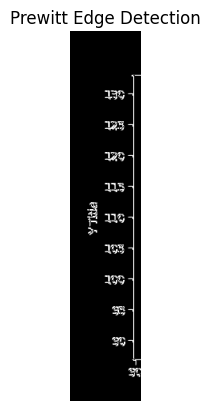

In [59]:
img_prewittx1 = cv2.filter2D(grey_first_verti, -1, kernelx)
img_prewitty1 = cv2.filter2D(grey_first_verti, -1, kernely)

img_prewitt1 = img_prewittx1 + img_prewitty1

plt.imshow(img_prewitt1, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

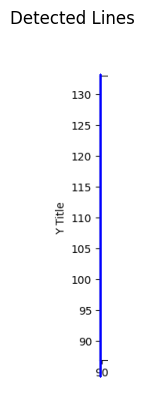

In [60]:
linesInFirstVeti = first_verti.copy()

_, binary_prewitt1 = cv2.threshold(img_prewitt1, 50, 255, cv2.THRESH_BINARY)
linesP1 = cv2.HoughLinesP(binary_prewitt1, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInFirstVeti, (x1, y1), (x2, y2), (255, 0, 0), 2)
        print()
    
linesInLastHori = cv2.cvtColor(linesInFirstVeti, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

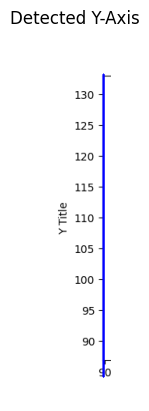

In [61]:
yAxisDetected = first_verti.copy()

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        if x1 > xMax and x2 > xMax:
            cv2.line(yAxisDetected, (x1, y1), (x2, y2), (255, 0, 0), 2)
            break
        
yAxisDetected = cv2.cvtColor(yAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(yAxisDetected )
plt.title('Detected Y-Axis')
plt.axis('off')
plt.show()

In [62]:
yAxisCords = [[x1, y1], [x2, y2]]
yAxisCords = sorted(yAxisCords, key=lambda x: x[1])
yAxisCords

[[81, 56], [81, 448]]

In [63]:
yAxisCord = 0

for i in yAxisCords:
    yAxisCord+=i[0]
    
yAxisCord = yAxisCord/2
yAxisCord

81.0

Detcted Both Axes 

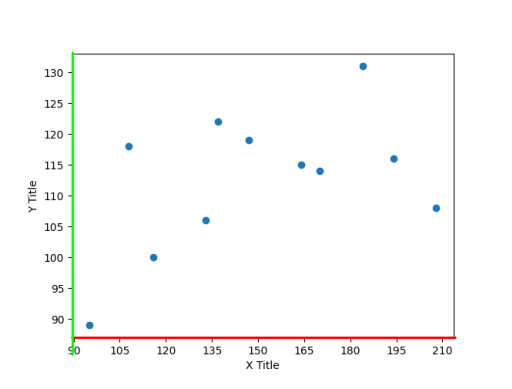

In [64]:
detectedAxes = image.copy()

cv2.line(detectedAxes, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (0, 0, 255), 2)
cv2.line(detectedAxes, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (0, 255, 0), 2)

# cv2.imshow('Image with Both Axes', detectedAxes)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.imshow(cv2.cvtColor(detectedAxes, cv2.COLOR_RGB2BGR))
plt.axis('off')
plt.show()

Chceck for Equal Pixel Distribution: X-Axis

In [65]:
most_common_pdiff_x = x_label['pdiff'][:-1].mode()[0]
most_common_pdiff_x

60.0

In [66]:
x_label[:1]

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,84.0,31.5,13.0,18.0,"[[75.0, 437.0], [93.0, 437.0], [93.0, 450.0], ...",15.0,59.0,0.254237,0.25


In [67]:
corVal_x = x_label['text'].iloc[0]
corFir_x = x_label['x_center'].iloc[0]
betweenFirst_x = abs(corFir_x - yAxisCord)

print(betweenFirst_x)

3.0


In [68]:
import math

corVal_x = x_label['text'].iloc[0]
corFir_x = x_label['x_center'].iloc[0]
betweenFirst_x = abs(yAxisCord - corFir_x)

if corVal_x == most_common_diff_x:
    if (betweenFirst_x > most_common_pdiff_x - 5) and (betweenFirst_x < most_common_pdiff_x + 5):
        # Case-1
        print("Case-1")
        toAdd_x = 0
        fromCal_x = yAxisCord
    else:
        # Case-5
        print("Case-5")
        toAdd_x = corVal_x
        fromCal_x = corFir_x
else:
    if (betweenFirst_x > most_common_pdiff_x - 5) and (betweenFirst_x < most_common_pdiff_x + 5):
        #Case-3
        print("Case-3")
        toAdd_x = corVal_x - most_common_diff_x
        fromCal_x = yAxisCord
    elif (betweenFirst_x < most_common_pdiff_x - 5):
        #Case-7
        print("Case-7")
        toAdd_x = corVal_x
        fromCal_x = corFir_x
    else:
        dif_x = betweenFirst_x/most_common_pdiff_x
        
        if dif_x - math.floor(dif_x) > 0.9:
            dif_x = math.ceil(dif_x)
        else:
            dif_x = math.floor(dif_x)
            
        # newCorVal = corVal - dif*most_common_diff
        # newCorFir = corFir - dif*most_common_pdiff
        fin_x = abs(betweenFirst_x - (dif_x)*most_common_pdiff_x)
        
        if fin_x < 5:
            newCorVal = corVal_x - (dif_x-1)*most_common_diff_x
            # newCorFir = corFir - (dif-1)*most_common_pdiff
            
            if newCorVal == most_common_diff_x:
                #Case-2
                print("Case-2")
                toAdd_x = 0
                fromCal_x = yAxisCord
            else:
                #Case-4
                print("Case-4")
                toAdd_x = corVal_x - (dif_x)*most_common_diff_x
                fromCal_x = yAxisCord
        else:
            newCorVal_x = corVal_x - (dif_x)*most_common_diff_x
            
            # if newCorVal == most_common_diff:
            
            #Case-6&8
            print("Case-6&8")
            toAdd_x = newCorVal_x
            fromCal_x = yAxisCord-fin_x
            
            # else:
            #     #Case-8
            #     toAdd = corVal - (dif)*most_common_diff
            #     fromCal = xAxisCord

Case-7


Chceck for Equal Pixel Distribution: Y-Axis

In [69]:
most_common_pdiff_y = y_label['pdiff'][:-1].mode()[0]
most_common_pdiff_y

40.0

In [70]:
y_label[-1:]

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
5,100.0,58.5,323.5,13.0,27.0,"[[45.0, 317.0], [72.0, 317.0], [72.0, 330.0], ...",NaN,NaN,NaN,NaN


In [71]:
corVal_y = y_label['text'].iloc[-1]
corFir_y = y_label['y_center'].iloc[-1]
betweenFirst_y = xAxisCord - corFir_y

print(betweenFirst_y)

102.5


In [72]:
corVal_y = y_label['text'].iloc[-1]
corFir_y = y_label['y_center'].iloc[-1]
betweenFirst_y = xAxisCord - corFir_y

if corVal_y == most_common_diff_y:
    if (betweenFirst_y > most_common_pdiff_y - 5) and (betweenFirst_y < most_common_pdiff_y + 5):
        # Case-1
        print("Case-1")
        toAdd_y = 0
        fromCal_y = xAxisCord
    else:
        # Case-5
        print("Case-5")
        toAdd_y = corVal_y
        fromCal_y = corFir_y
else:
    if (betweenFirst_y > most_common_pdiff_y - 5) and (betweenFirst_y < most_common_pdiff_y + 5):
        #Case-3
        print("Case-3")
        toAdd_y = corVal_y - most_common_diff_y
        fromCal_y = xAxisCord
    elif (betweenFirst_y < most_common_pdiff_y - 5):
        #Case-7
        print("Case-7")
        toAdd_y = corVal_y
        fromCal_y = corFir_y
    else:
        dif_y = betweenFirst_y/most_common_pdiff_y
        
        if dif_y - math.floor(dif_y) > 0.9:
            dif_y = math.ceil(dif_y)
        else:
            dif_y = math.floor(dif_y)
            
        # newCorVal = corVal - dif*most_common_diff
        # newCorFir = corFir - dif*most_common_pdiff
        fin_y = abs(betweenFirst_y - (dif_y)*most_common_pdiff_y)
        
        if fin_y < 5:
            newCorVal_y = corVal_y - (dif_y-1)*most_common_diff_y
            # newCorFir = corFir - (dif-1)*most_common_pdiff
            
            if newCorVal_y == most_common_diff_y:
                #Case-2
                print("Case-2")
                toAdd_y = 0
                fromCal_y = xAxisCord
            else:
                #Case-4
                print("Case-4")
                toAdd_y = corVal_y - (dif_y)*most_common_diff_y
                fromCal_y = xAxisCord
        else:
            newCorVal_y = corVal_y - (dif_y)*most_common_diff_y
            
            # if newCorVal == most_common_diff:
            
            #Case-6&8
            print("Case-6&8")
            toAdd_y = newCorVal_y
            fromCal_y = xAxisCord-fin_y
            
            # else:
            #     #Case-8
            #     toAdd = corVal - (dif)*most_common_diff
            #     fromCal = xAxisCord

Case-6&8


Detcting Color for Binarization

Croping Image

In [73]:
yAxisCords

[[81, 56], [81, 448]]

In [74]:
xAxisCords

[[80, 426], [578, 426]]

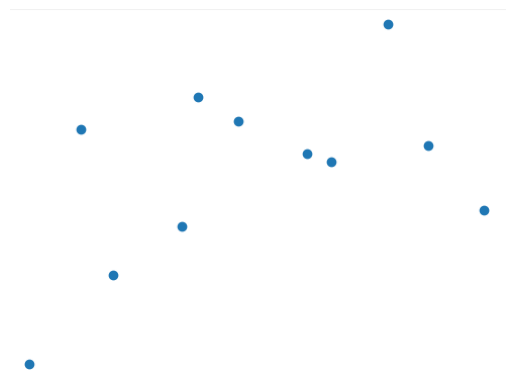

In [75]:
fropTop = yAxisCords[0][1]+3
toBottom = xAxisCords[0][1]-3

fromLeft = (yAxisCords[0][0] + yAxisCords[1][0])//2+3
toRight = xAxisCords[1][0]-3

imagePart = image[fropTop:toBottom, fromLeft:toRight]

plt.imshow(cv2.cvtColor(imagePart, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
# cv2.imshow('part', imagePart)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

Color Detection

In [76]:
imagePart1 = cv2.cvtColor(imagePart, cv2.COLOR_BGR2RGB)

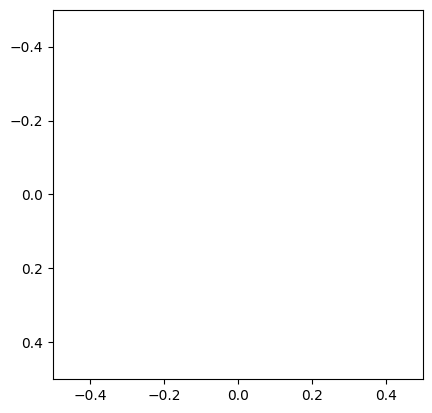

[255.62701 255.62723 255.6281 ]


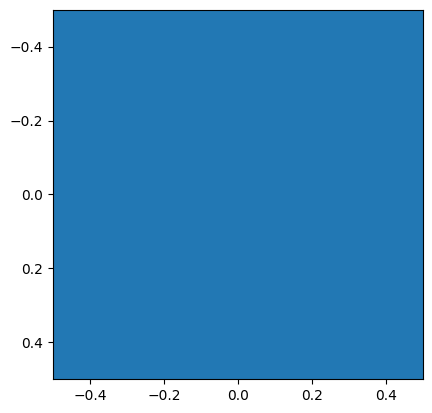

[ 34.04348 120.73913 180.92754]


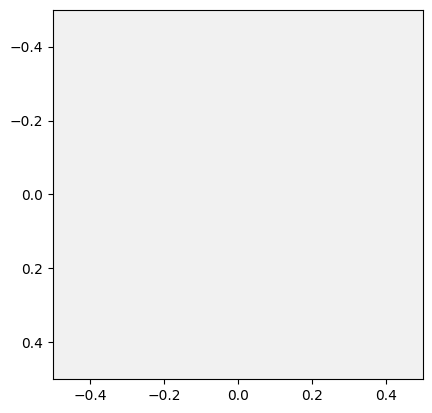

[241.00002 241.00002 241.00002]


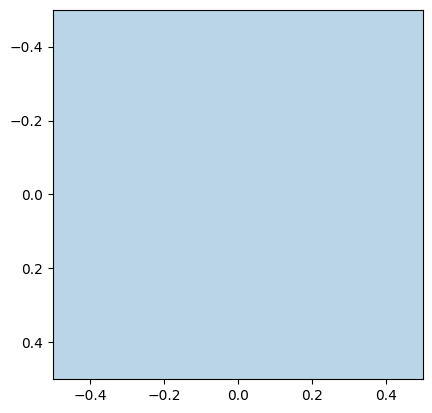

[187.59999 213.79999 232.     ]


In [77]:
pixels = imagePart1.reshape((-1, 3)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 4

_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

unique, counts = np.unique(labels, return_counts=True)

sorted_colors = sorted(zip(counts, centers), key=lambda x: x[0], reverse=True)

sorted_colors = [tpl[1] for tpl in sorted_colors]

for color in sorted_colors:
    plt.imshow([[color.astype(np.uint8)/255]])
    plt.show()
    print(color)

In [78]:
modified_image = np.copy(imagePart1)

# Assign white color to pixels belonging to the 2nd cluster and black color to pixels belonging to other clusters
for idx, color in enumerate(centers):
    if idx == 1:  # Assuming the 2nd cluster (index starts from 0)
        mask = (labels == idx).reshape(imagePart1.shape[:2])
        modified_image[mask] = [255, 255, 255]  # White color
    else:
        mask = (labels == idx).reshape(imagePart1.shape[:2])
        modified_image[mask] = [0, 0, 0]  # Black color

cv2.imshow('Original Image', cv2.cvtColor(imagePart1, cv2.COLOR_BGR2RGB))
cv2.imshow('Modified Image', modified_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

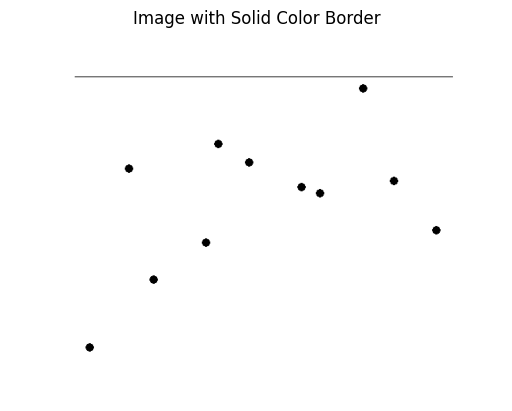

In [79]:
border_color = [255, 255, 255]

image_with_border = cv2.copyMakeBorder(modified_image, fropTop, (height - toBottom), fromLeft, (width - toRight), cv2.BORDER_CONSTANT, value=border_color)

plt.imshow(cv2.cvtColor(image_with_border, cv2.COLOR_BGR2RGB))
plt.title("Image with Solid Color Border")
plt.axis('off')
plt.show()

Dots Detection

In [80]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [81]:
gray_Dots = cv2.cvtColor(image_with_border, cv2.COLOR_BGR2GRAY)

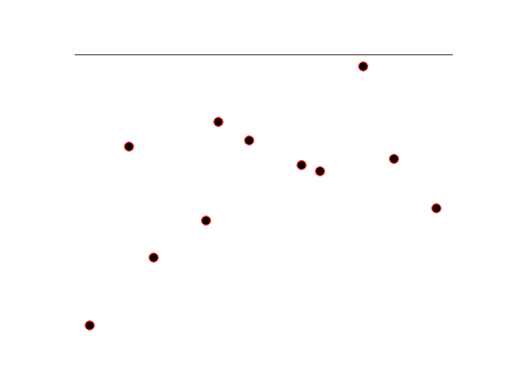

In [82]:
# Setup SimpleBlobDetector parameters.
params = cv2.SimpleBlobDetector_Params()

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

params.filterByArea = True
params.minArea = 10
params.maxArea = 2000

# Create a detector with the parameters
detector = cv2.SimpleBlobDetector_create(params)
    
# Detect blobs.
keypoints = detector.detect(gray_Dots)

imageABC = image_with_border.copy()
imageABC = cv2.drawKeypoints(imageABC, keypoints, None, (255,0,0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(imageABC)
plt.axis('off')

plt.show()

In [83]:
len(keypoints)

11

In [84]:
finPointsCor = []

for kp in keypoints:
    x = kp.pt[0]  
    y = kp.pt[1] 
    finPointsCor.append((x,y)) 

In [85]:
toAdd_x

90.0

In [86]:
toAdd_y

90.0

In [87]:
finPointsCor

[(103.0, 410.0),
 (186.0, 322.0),
 (254.0, 274.0),
 (553.0, 258.0),
 (402.0, 210.0),
 (378.0, 202.0),
 (498.0, 194.0),
 (154.0, 178.0),
 (310.0, 170.0),
 (270.0, 146.0),
 (458.0, 74.0)]

In [88]:
finPointVal = []

for point in finPointsCor:
    x, y = point
    
    if x < fromCal_x:
        temp_x = abs(x - fromCal_x)*vpp_x
        finalVal_x = abs(toAdd_x - temp_x)
    else:
        finalVal_x = abs(x - fromCal_x)*vpp_x + toAdd_x
        
    if y > fromCal_y:
        temp_y = abs(y - fromCal_y)*vpp_y
        finalVal_y = abs(toAdd_y - temp_y)
    else:
        finalVal_y = abs(y - fromCal_y)*vpp_y + toAdd_y
    finPointVal.append([finalVal_x, finalVal_y])

finPointVal

[[94.76352804043596, 89.1875],
 [115.57262421707722, 100.1875],
 [132.62104036179537, 106.1875],
 [207.58392899812958, 108.1875],
 [169.72641667677016, 114.1875],
 [163.70932862569316, 115.1875],
 [193.79476888107814, 116.1875],
 [107.54984014897457, 118.1875],
 [146.660912480975, 119.1875],
 [136.6324323958467, 122.1875],
 [183.7662887959498, 131.1875]]

In [89]:
data_x = pd.read_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Scatter\\Testing\\testDataX.csv')

In [90]:
data_y = pd.read_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Scatter\\Testing\\testDataY.csv')

In [91]:
final = pd.DataFrame(finPointVal, columns=[xtitle, ytitle])
final

,x title,ytitle
0,94.763528,89.1875
1,115.572624,100.1875
2,132.621040,106.1875
3,207.583929,108.1875
4,169.726417,114.1875
5,163.709329,115.1875
6,193.794769,116.1875
7,107.549840,118.1875
8,146.660912,119.1875
9,136.632432,122.1875


In [92]:
dataX = data_x[str(ImageNumber)].dropna()
final['actuals_x'] = dataX

dataY = data_y[str(ImageNumber)].dropna()
final['actuals_y'] = dataY

final

,x title,ytitle,actuals_x,actuals_y
0,94.763528,89.1875,137.0,122.0
1,115.572624,100.1875,133.0,106.0
2,132.621040,106.1875,108.0,118.0
3,207.583929,108.1875,95.0,89.0
4,169.726417,114.1875,170.0,114.0
5,163.709329,115.1875,116.0,100.0
6,193.794769,116.1875,164.0,115.0
7,107.549840,118.1875,194.0,116.0
8,146.660912,119.1875,208.0,108.0
9,136.632432,122.1875,184.0,131.0


In [95]:
final.to_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Scatter\\Testing\\testImages\\' + f'{str(ImageNumber)}\\{str(ImageNumber)}.csv', index=False, sep=',', encoding='utf-8')

In [97]:
pd.read_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Scatter\\Testing\\testImages\\' + f'{str(ImageNumber)}\\{str(ImageNumber)}.csv')

,x title,ytitle,actuals_x,actuals_y
0,94.763528,89.1875,137.0,122.0
1,115.572624,100.1875,133.0,106.0
2,132.621040,106.1875,108.0,118.0
3,207.583929,108.1875,95.0,89.0
4,169.726417,114.1875,170.0,114.0
5,163.709329,115.1875,116.0,100.0
6,193.794769,116.1875,164.0,115.0
7,107.549840,118.1875,194.0,116.0
8,146.660912,119.1875,208.0,108.0
9,136.632432,122.1875,184.0,131.0


Showcase

In [98]:
np.array(finPointVal)[:,0]

array([ 94.76352804, 115.57262422, 132.62104036, 207.583929  ,
       169.72641668, 163.70932863, 193.79476888, 107.54984015,
       146.66091248, 136.6324324 , 183.7662888 ])

In [99]:
%pwd

'c:\\College\\Sem 08\\Major Project\\Graphs\\Scatter'

In [100]:
toAdd_x

90.0

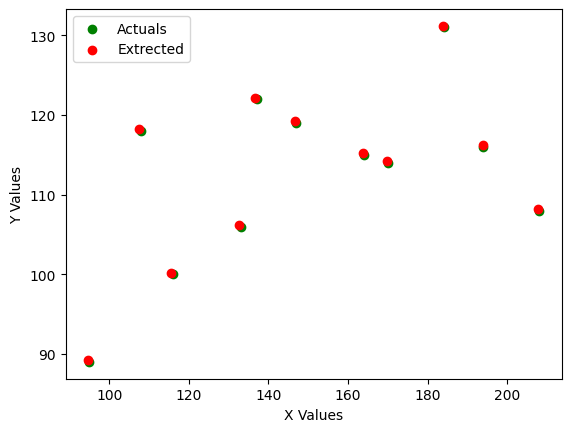

In [101]:
plt.scatter(final['actuals_x'], final['actuals_y'], c="g", label='Actuals')
plt.scatter(np.array(finPointVal)[:,0], np.array(finPointVal)[:,1], c="r", label='Extrected')
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.legend()
plt.show()


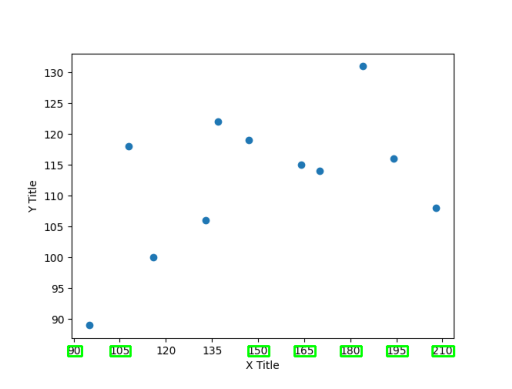

In [102]:
image11 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1223 = image11.copy()

for indx in x_label_copy.index:
    box = x_label_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

In [103]:
x_title_copy = x_title.copy()

for index, row in x_title_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_title_copy.at[index, 'box'] = arr

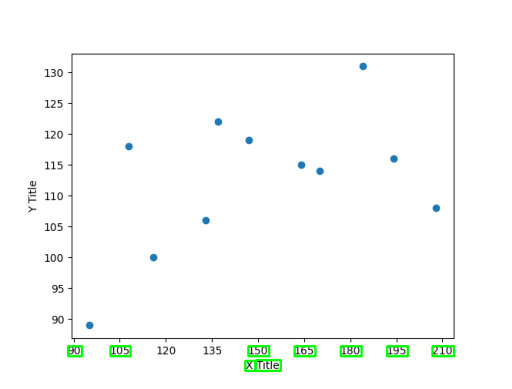

In [104]:
for indx in x_title_copy.index:
    box = x_title_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

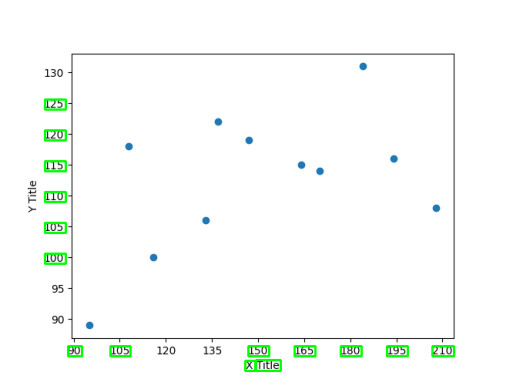

In [105]:
for indx in y_label.index:
    box = y_label['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

In [106]:
blahblah = [4]

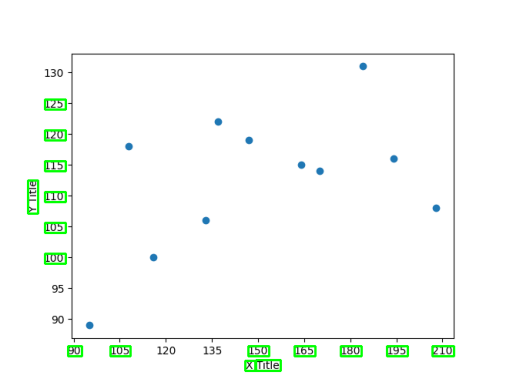

In [107]:
for indx in df1.index:
    if indx in blahblah:
        box = df1['box'][indx]
        box = box.astype(int)
        cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show() 

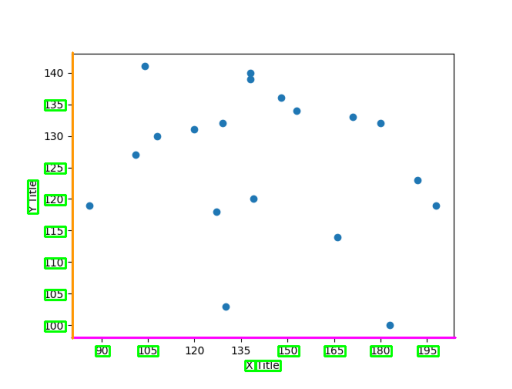

In [103]:
cv2.line(image1223, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (255, 0, 255), 2)
cv2.line(image1223, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (255, 150, ), 2)

plt.imshow(image1223)
plt.axis('off')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

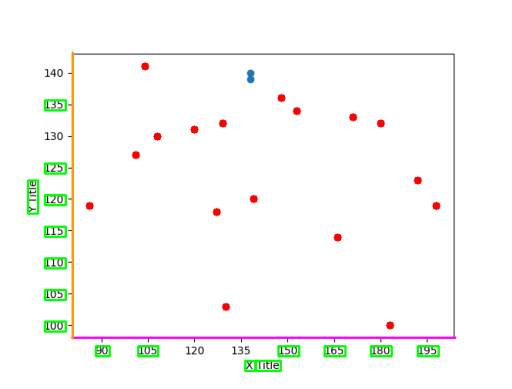

In [104]:
for point in finPointsCor:
    x, y = point
    cv2.circle(image1223, (int(x), int(y)), 5, (255, 0, 0), -1)

plt.imshow(image1223)
plt.axis('off')
plt.show